# Raw Data Plotter (No Filter)

This notebook follows the plotting workflow in `Tuner.ipynb`, but it reads the experiment log directly and does **not** apply spline / SG / Butterworth filtering.

- It still splits the mixed CSV by `Mode=...` and `Value=...` command markers.
- It keeps the same `phi -> x_c` conversion factor (`0.2527`).
- If you plot velocity, it computes a direct finite-difference velocity from raw `x_c`.
- Time is reset so each segment starts at `t = 0`, but signals are left raw by default.


In [50]:
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

SEGWAY_DIR = Path('/Users/a123/Documents/Unicycle/Matlab_Simu4Unicycle/Derivation/Segway')
PLOT_OUTPUT_DIR = SEGWAY_DIR / 'Plots' / 'raw_data_no_filter'

RAW_MAIN_COLOR = '#3860e0'
RAW_GAMMA_COLOR = '#f59e0b'
TARGET_COLOR = '#dc2626'


def activate_inline_matplotlib():
    try:
        from IPython import get_ipython
        ipython = get_ipython()
        if ipython is not None:
            ipython.run_line_magic('matplotlib', 'inline')
        plt.switch_backend('module://matplotlib_inline.backend_inline')
    except Exception as exc:
        print(f'Could not switch matplotlib to inline backend: {exc}')


activate_inline_matplotlib()


def safe_plot_filename(title):
    return ''.join(char if char.isalnum() else '_' for char in title).strip('_').lower()


def save_and_show_figure(fig, title):
    output_dir = PLOT_OUTPUT_DIR
    try:
        output_dir.mkdir(parents=True, exist_ok=True)
    except PermissionError:
        output_dir = Path('/tmp/unicycle_mujoco_plots') / PLOT_OUTPUT_DIR.name
        output_dir.mkdir(parents=True, exist_ok=True)
        print(f'Plot directory was not writable; using fallback: {output_dir}')

    output_path = output_dir / f'{safe_plot_filename(title)}.png'
    fig.savefig(output_path, dpi=160, bbox_inches='tight')
    print(f'Plot saved to: {output_path}')
    plt.show()
    return output_path


def style_axis(axis):
    axis.grid(False)
    axis.spines['top'].set_visible(False)
    axis.spines['right'].set_visible(False)
    axis.tick_params(direction='out')


def style_legend(axis):
    axis.legend(frameon=False)


In [51]:
def parse_mixed_csv_raw(file_path, phi_to_xc_scale=0.2527):
    file_path = Path(file_path)
    if not file_path.exists():
        raise FileNotFoundError(f'CSV file not found: {file_path}')

    mode_segments = []
    current_mode = 'balance'
    current_target = 0.0
    current_data = []
    command_pattern = re.compile(r'Mode=(\w+),\s*Value=([\d\.-]+)')

    with file_path.open('r', encoding='utf-8') as handle:
        for raw_line in handle:
            line = raw_line.strip()
            if not line:
                continue

            if line.startswith('"--- SEND COMMAND:'):
                if current_data:
                    mode_segments.append({
                        'mode': current_mode,
                        'target_value': current_target,
                        'data': current_data,
                    })

                match = command_pattern.search(line)
                if match:
                    current_mode = match.group(1)
                    current_target = float(match.group(2))

                current_data = []
                continue

            if line[0].isdigit() or line[0] == '-':
                try:
                    row = [float(value) for value in line.split(',')]
                except ValueError:
                    continue

                if len(row) > 3:
                    row[3] = row[3] * phi_to_xc_scale
                current_data.append(row)

    if current_data:
        mode_segments.append({
            'mode': current_mode,
            'target_value': current_target,
            'data': current_data,
        })

    return mode_segments


def append_raw_velocity(segment_rows):
    if segment_rows is None or len(segment_rows) < 2:
        return segment_rows

    rows_with_velocity = [list(row) for row in segment_rows]
    for index, row in enumerate(rows_with_velocity):
        while len(row) < 5:
            row.append(0.0)

        if index == 0:
            row[4] = 0.0
            continue

        dt = row[0] - rows_with_velocity[index - 1][0]
        dx = row[3] - rows_with_velocity[index - 1][3]
        row[4] = dx / dt if dt != 0 else 0.0

    return rows_with_velocity


def relative_time_only(segment_rows):
    if not segment_rows:
        return segment_rows

    start_time = segment_rows[0][0]
    shifted_rows = []
    for row in segment_rows:
        new_row = list(row)
        new_row[0] = row[0] - start_time
        shifted_rows.append(new_row)
    return shifted_rows


def zero_all_signals(segment_rows):
    if not segment_rows:
        return segment_rows

    start_row = segment_rows[0]
    shifted_rows = []
    for row in segment_rows:
        new_row = [row[0]]
        for column_index in range(1, len(row)):
            new_row.append(row[column_index] - start_row[column_index])
        shifted_rows.append(new_row)
    return shifted_rows


def collect_raw_segments(
    file_paths,
    mode_name,
    target_value,
    value_column,
    runs_per_file=3,
    time_limit=15,
    exclude_run_indices=None,
    zero_signals=False,
):
    exclude_run_indices = set(exclude_run_indices or [])
    collected = []
    run_index = 0

    for file_path in file_paths:
        segments = parse_mixed_csv_raw(file_path)
        selected_segments = [
            item['data']
            for item in segments
            if item['mode'] == mode_name and np.isclose(item['target_value'], target_value)
        ]

        for segment_rows in selected_segments[:runs_per_file]:
            rows = segment_rows
            if value_column == 4:
                rows = append_raw_velocity(rows)

            rows = relative_time_only(rows)
            if zero_signals:
                rows = zero_all_signals(rows)

            trimmed_rows = [row for row in rows if row[0] <= time_limit]
            if not trimmed_rows:
                continue

            if run_index in exclude_run_indices:
                run_index += 1
                continue

            time = np.array([row[0] for row in trimmed_rows], dtype=float)
            value = np.array([row[value_column] for row in trimmed_rows], dtype=float)
            gamma_deg = np.degrees(np.array([row[2] for row in trimmed_rows], dtype=float))

            collected.append({
                'run_index': run_index,
                'file_path': str(file_path),
                'time': time,
                'value': value,
                'gamma_deg': gamma_deg,
            })
            run_index += 1

    if not collected:
        raise ValueError(
            f'No matching raw segments found for mode={mode_name!r}, target={target_value!r}.'
        )

    return collected


def plot_raw_mode(
    title,
    file_paths,
    mode_name,
    target_value,
    value_column,
    value_label,
    runs_per_file=3,
    time_limit=15,
    exclude_run_indices=None,
    zero_signals=True,
):
    segments = collect_raw_segments(
        file_paths=file_paths,
        mode_name=mode_name,
        target_value=target_value,
        value_column=value_column,
        runs_per_file=runs_per_file,
        time_limit=time_limit,
        exclude_run_indices=exclude_run_indices,
        zero_signals=zero_signals,
    )

    fig, ax = plt.subplots(figsize=(10, 4.5))

    for index, segment in enumerate(segments):
        label_suffix = f"run {segment['run_index']}"
        ax.plot(
            segment['time'],
            segment['value'],
            color=RAW_MAIN_COLOR,
            linewidth=1.8,
            #alpha=0.35 + 0.45 * (index == 0),
            alpha=0.4,
            label=value_label if index == 0 else None,
        )

    if not zero_signals:
        ax.axhline(target_value, color=TARGET_COLOR, linestyle='--', linewidth=1.2, label=f'Target {target_value:g}')

    ax.set_title(title)
    ax.set_ylabel(value_label)
    ax.set_xlabel('Time (s)')

    style_axis(ax)
    style_legend(ax)

    save_and_show_figure(fig, title)
    return segments


## Velocity Mode Example

This uses the same velocity log files that appear in `Tuner.ipynb`. The plotted velocity is a raw finite-difference result from unfiltered `x_c`.


Plot saved to: /Users/a123/Documents/Unicycle/Matlab_Simu4Unicycle/Derivation/Segway/Plots/raw_data_no_filter/velocity_mode_raw_data__no_filter.png


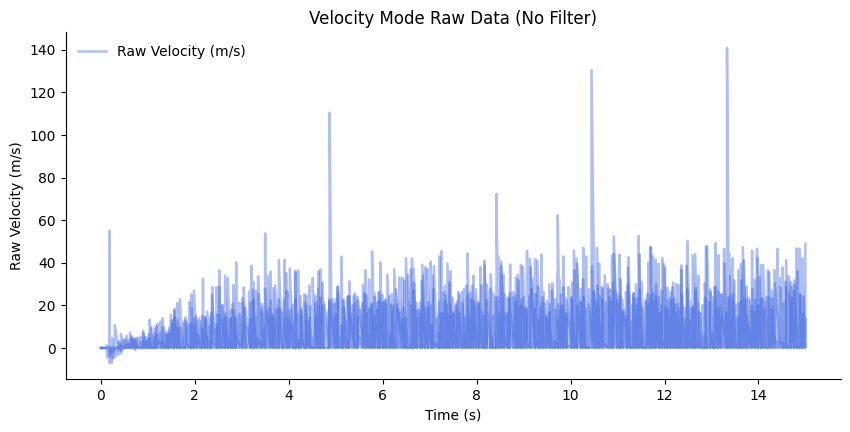

3

In [52]:
velocity_raw_filenames = [
    '/Users/a123/Documents/Unicycle/unicycle_project_umich/LOGS/ValidLogs/V0.5x3.csv',
    '/Users/a123/Documents/Unicycle/unicycle_project_umich/LOGS/ValidLogs/V0.5x3(2).csv',
]

velocity_segments = plot_raw_mode(
    title='Velocity Mode Raw Data (No Filter)',
    file_paths=velocity_raw_filenames,
    mode_name='velocity',
    target_value=0.5,
    value_column=4,
    value_label='Raw Velocity (m/s)',
    runs_per_file=3,
    time_limit=15,
    exclude_run_indices=[2, 4, 5],
    zero_signals=True,
)

len(velocity_segments)


## Position Mode Example

This plots the raw `x_c` signal directly, still using the same `phi -> x_c` scale factor as the rest of the Segway tooling.


Plot saved to: /Users/a123/Documents/Unicycle/Matlab_Simu4Unicycle/Derivation/Segway/Plots/raw_data_no_filter/position_mode_raw_data__no_filter.png


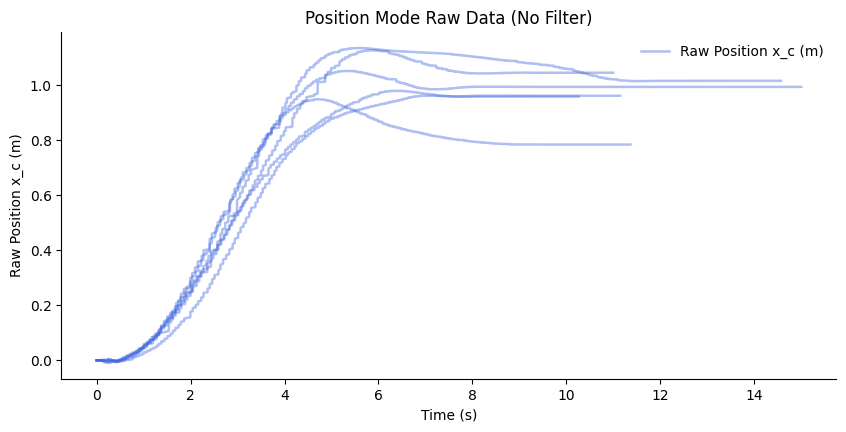

6

In [53]:
position_raw_filenames = [
    '/Users/a123/Documents/Unicycle/unicycle_project_umich/LOGS/ValidLogs/P1.0x3.csv',
    '/Users/a123/Documents/Unicycle/unicycle_project_umich/LOGS/ValidLogs/P1.0x3(2).csv',
]

position_segments = plot_raw_mode(
    title='Position Mode Raw Data (No Filter)',
    file_paths=position_raw_filenames,
    mode_name='position',
    target_value=1.0,
    value_column=3,
    value_label='Raw Position x_c (m)',
    runs_per_file=3,
    time_limit=15,
    exclude_run_indices=None,
    zero_signals=True,
)

len(position_segments)


## Velocity Mode Individual Raw Runs

This section keeps the data unfiltered, but draws three velocity-mode runs separately so each run is easier to inspect.


Plot saved to: /Users/a123/Documents/Unicycle/Matlab_Simu4Unicycle/Derivation/Segway/Plots/raw_data_no_filter/velocity_mode_raw_run_1_no_filter.png


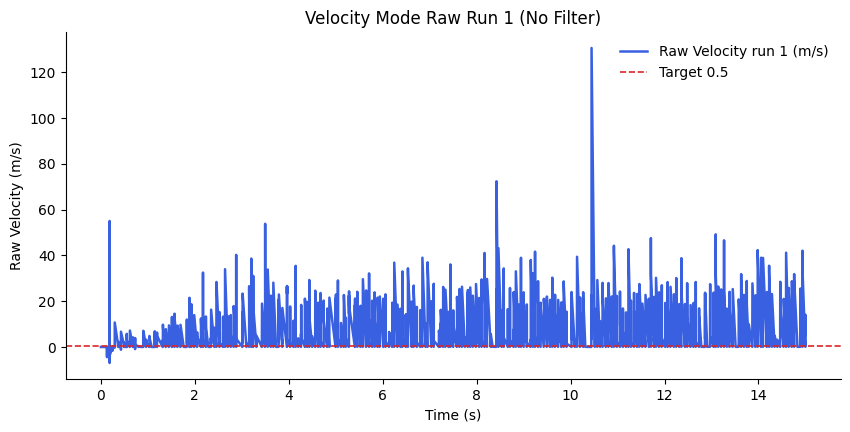

Plot saved to: /Users/a123/Documents/Unicycle/Matlab_Simu4Unicycle/Derivation/Segway/Plots/raw_data_no_filter/velocity_mode_raw_run_2_no_filter.png


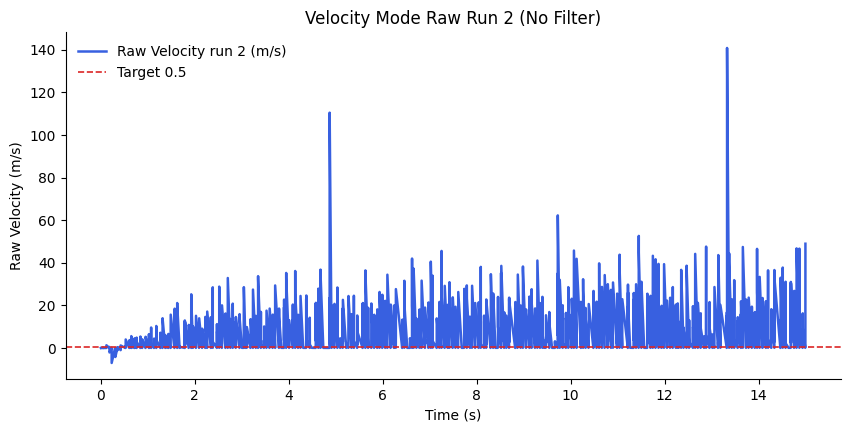

Plot saved to: /Users/a123/Documents/Unicycle/Matlab_Simu4Unicycle/Derivation/Segway/Plots/raw_data_no_filter/velocity_mode_raw_run_3_no_filter.png


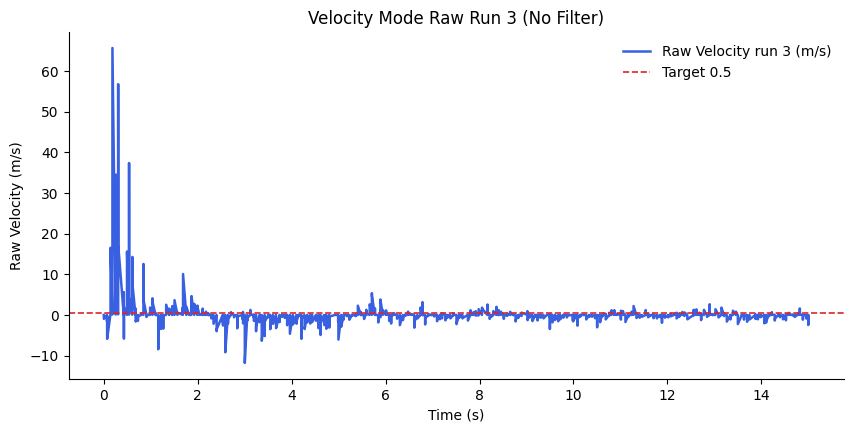

[PosixPath('/Users/a123/Documents/Unicycle/Matlab_Simu4Unicycle/Derivation/Segway/Plots/raw_data_no_filter/velocity_mode_raw_run_1_no_filter.png'),
 PosixPath('/Users/a123/Documents/Unicycle/Matlab_Simu4Unicycle/Derivation/Segway/Plots/raw_data_no_filter/velocity_mode_raw_run_2_no_filter.png'),
 PosixPath('/Users/a123/Documents/Unicycle/Matlab_Simu4Unicycle/Derivation/Segway/Plots/raw_data_no_filter/velocity_mode_raw_run_3_no_filter.png')]

In [54]:
def plot_velocity_runs_separately(
    file_paths,
    target_value=0.5,
    runs_per_file=3,
    time_limit=15,
    run_count=3,
    zero_signals=False,
):
    segments = collect_raw_segments(
        file_paths=file_paths,
        mode_name='velocity',
        target_value=target_value,
        value_column=4,
        runs_per_file=runs_per_file,
        time_limit=time_limit,
        exclude_run_indices=None,
        zero_signals=zero_signals,
    )

    selected_segments = segments[:run_count]
    if len(selected_segments) < run_count:
        print(f'Only found {len(selected_segments)} matching velocity runs.')

    plotted_paths = []
    for plot_index, segment in enumerate(selected_segments, start=1):
        fig, ax = plt.subplots(figsize=(10, 4.5))

        ax.plot(
            segment['time'],
            segment['value'],
            color=RAW_MAIN_COLOR,
            linewidth=1.8,
            label=f"Raw Velocity run {plot_index} (m/s)",
        )
        if not zero_signals:
            ax.axhline(
                target_value,
                color=TARGET_COLOR,
                linestyle='--',
                linewidth=1.2,
                label=f'Target {target_value:g}',
            )

        ax.set_title(f'Velocity Mode Raw Run {plot_index} (No Filter)')
        ax.set_ylabel('Raw Velocity (m/s)')
        # ax.set_ylim(-0.1, 1.0)
        ax.set_xlabel('Time (s)')

        style_axis(ax)
        style_legend(ax)

        plotted_paths.append(
            save_and_show_figure(fig, f'velocity_mode_raw_run_{plot_index}_no_filter')
        )

    return selected_segments, plotted_paths


velocity_individual_segments, velocity_individual_paths = plot_velocity_runs_separately(
    file_paths=velocity_raw_filenames,
    target_value=0.5,
    runs_per_file=3,
    time_limit=15,
    run_count=3,
    zero_signals=False,
)

velocity_individual_paths


## Notes

- Set `zero_signals=True` in `plot_raw_mode(...)` if you want the plot to start from zero like the filtered pipeline.
- Keep `value_column=3` for raw position (`x_c`) and `value_column=4` for raw finite-difference velocity.
- If you want to point to different logs, just edit the `*_raw_filenames` lists above.
